## <span style="color:grey; font-weight:bold;">Import Tools and Def Functions</span>

In [16]:
import pandas as pd
import os
import missingno as msno
import sys
import importlib
import Def_Function

sys.path.append('/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis')

In [42]:
importlib.reload(Def_Function)

from Def_Function import RenameandCheckDuplicateandNaN, ColumnsNaNSorted, RemovedColumnOver50, SeparateNumericalandObjective
from Def_Function import ColumnsHist, CorrHeatMap, CountStatistic, ImputeNaN, ObjectiveLabelEncoder, NaNColumns, MergeAllTypeofColumns
from Def_Function import FilterColumns, DropSpecificRowNaN, ModelFillNaN, CheckNegativeColumns, SkewCountingandTransformWithoutHist
from Def_Function import BoxPlot, SaveCSV

In [18]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [19]:
data_path = '/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis/Data'
os.chdir(data_path)

files = os.listdir()
print(files)

['.DS_Store', 'train.txt', 'readme.txt', 'test.txt']


## <span style="color:grey; font-weight:bold;">Import Data and Separate Chunk</span>

In [20]:
read_chunk = pd.read_csv('train.txt', sep='\t', chunksize=10000000, iterator=True)

total_rows = 0

for i, chunk in enumerate(read_chunk, start=1):
    print(f'Processing Chunk {i}')

    total_rows += chunk.shape[0]
    
    chunk.to_csv(f'Base Train DataFrame Chunk{i}.csv', index=False)

    print(f'Chunk {i} Finished.')

print(f'Total Rows in Train Data: {total_rows}')

Processing Chunk 1
Chunk 1 Finished.
Processing Chunk 2
Chunk 2 Finished.
Processing Chunk 3
Chunk 3 Finished.
Processing Chunk 4
Chunk 4 Finished.
Processing Chunk 5
Chunk 5 Finished.
Total Rows in Train Data: 45840616


## <span style="color:skyblue; font-weight:bold;">Chunk 1</span>

#### <span style="color:grey; font-weight:bold;">EDA</span>

In [21]:
df_chunk1 = pd.read_csv('Base Train DataFrame Chunk1.csv', sep=',')
df_chunk1

,0,1,1.1,5,0.1,1382,4,15,2,181,...,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,Unnamed: 35,3a171ecb,c5c50484,e8b83407,9727dd16
0,0,2.00,0,44.00,1.00,102.00,8.00,2.00,2.00,4.00,...,07c540c4,b04e4670,21ddcdc9,5840adea,60f6221e,NaN,3a171ecb,43f13e8b,e8b83407,731c3655
1,0,2.00,0,1.00,14.00,767.00,89.00,4.00,2.00,245.00,...,8efede7f,3412118d,NaN,NaN,e587c466,ad3062eb,3a171ecb,3b183c5c,NaN,NaN
2,0,NaN,893,NaN,NaN,4392.00,NaN,0.00,0.00,0.00,...,1e88c74f,74ef3502,NaN,NaN,6b3a5ca6,NaN,3a171ecb,9117a34a,NaN,NaN
3,0,3.00,-1,NaN,0.00,2.00,0.00,3.00,0.00,0.00,...,1e88c74f,26b3c7a7,NaN,NaN,21c9516a,NaN,32c7478e,b34f3128,NaN,NaN
4,0,NaN,-1,NaN,NaN,12824.00,NaN,0.00,0.00,6.00,...,776ce399,92555263,NaN,NaN,242bb710,8ec974f4,be7c41b4,72c78f11,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,1,NaN,2,38.00,NaN,17425.00,89.00,1.00,9.00,2.00,...,d4bb7bd8,4bcc9449,712d530c,b1252a9d,49885a68,c9d4222a,32c7478e,e22fed0c,47907db5,4a4b8a48
9999996,0,0.00,84,2.00,2.00,2825.00,100.00,36.00,12.00,179.00,...,8efede7f,f3644223,21ddcdc9,b1252a9d,780bdc55,NaN,bcdee96c,2f647dfe,f0f449dd,52d71dab
9999997,1,NaN,13,NaN,1.00,7225.00,NaN,0.00,1.00,12.00,...,776ce399,df5475ca,NaN,NaN,3b226dea,c9d4222a,32c7478e,4fcc135f,NaN,NaN
9999998,0,NaN,0,28.00,17.00,4344.00,NaN,0.00,31.00,193.00,...,e5ba7672,d4328054,NaN,NaN,0014c32a,ad3062eb,bcdee96c,3b183c5c,NaN,NaN


In [22]:
df_chunk1.shape

(10000000, 40)

In [23]:
df_chunk1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 40 columns):
 #   Column       Dtype  
---  ------       -----  
 0   0            int64  
 1   1            float64
 2   1.1          int64  
 3   5            float64
 4   0.1          float64
 5   1382         float64
 6   4            float64
 7   15           float64
 8   2            float64
 9   181          float64
 10  1.2          float64
 11  2.1          float64
 12  Unnamed: 12  float64
 13  2.2          float64
 14  68fd1e64     object 
 15  80e26c9b     object 
 16  fb936136     object 
 17  7b4723c4     object 
 18  25c83c98     object 
 19  7e0ccccf     object 
 20  de7995b8     object 
 21  1f89b562     object 
 22  a73ee510     object 
 23  a8cd5504     object 
 24  b2cb9c98     object 
 25  37c9c164     object 
 26  2824a5f6     object 
 27  1adce6ef     object 
 28  8ba8b39a     object 
 29  891b62e7     object 
 30  e5ba7672     object 
 31  f54016b9     object 
 3

In [24]:
df_chunk1.describe()

,0,1,1.1,5,0.1,1382,4,15,2,181,1.2,2.1,Unnamed: 12,2.2
count,10000000.00,5569241.00,10000000.00,7851197.00,7795890.00,9727499.00,7717330.00,9557965.00,9994534.00,9557965.00,5569241.00,9557965.00,2304637.00,7795890.00
mean,0.25,3.32,105.75,22.83,7.26,18838.03,117.66,15.32,12.64,104.53,0.60,2.58,0.95,8.15
std,0.43,9.00,385.65,296.38,8.78,69638.22,376.38,62.74,21.27,218.48,0.68,4.99,5.25,21.53
min,0.00,0.00,-3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,2.00,2.00,403.00,8.00,1.00,2.00,10.00,0.00,1.00,0.00,2.00
50%,0.00,1.00,3.00,6.00,4.00,2763.00,33.00,3.00,7.00,38.00,1.00,1.00,0.00,4.00
75%,1.00,3.00,36.00,17.00,9.00,10252.00,103.00,11.00,19.00,107.00,1.00,3.00,0.00,10.00
max,1.00,1539.00,22066.00,65535.00,561.00,2655388.00,233523.00,26297.00,5106.00,24376.00,9.00,181.00,1807.00,6879.00


#### <span style="color:grey; font-weight:bold;">Rename & Deleted Duplicated</span>

In [25]:
df_chunk1= RenameandCheckDuplicateandNaN(df_chunk1)

Rename is Finished.

Duplicates Found.
Duplicates Rows Count: 1343
New Shape After Removing Duplicates: (9998657, 40)
NaN Found.
Total NaN Value: 55488983



#### <span style="color:grey; font-weight:bold;">Objective LabelEncoder</span>

In [26]:
df_chunk1 = ObjectiveLabelEncoder(df_chunk1)

encoder_dict is None
Joblib Saved



#### <span style="color:grey; font-weight:bold;">HistPlot & HeatMap</span>

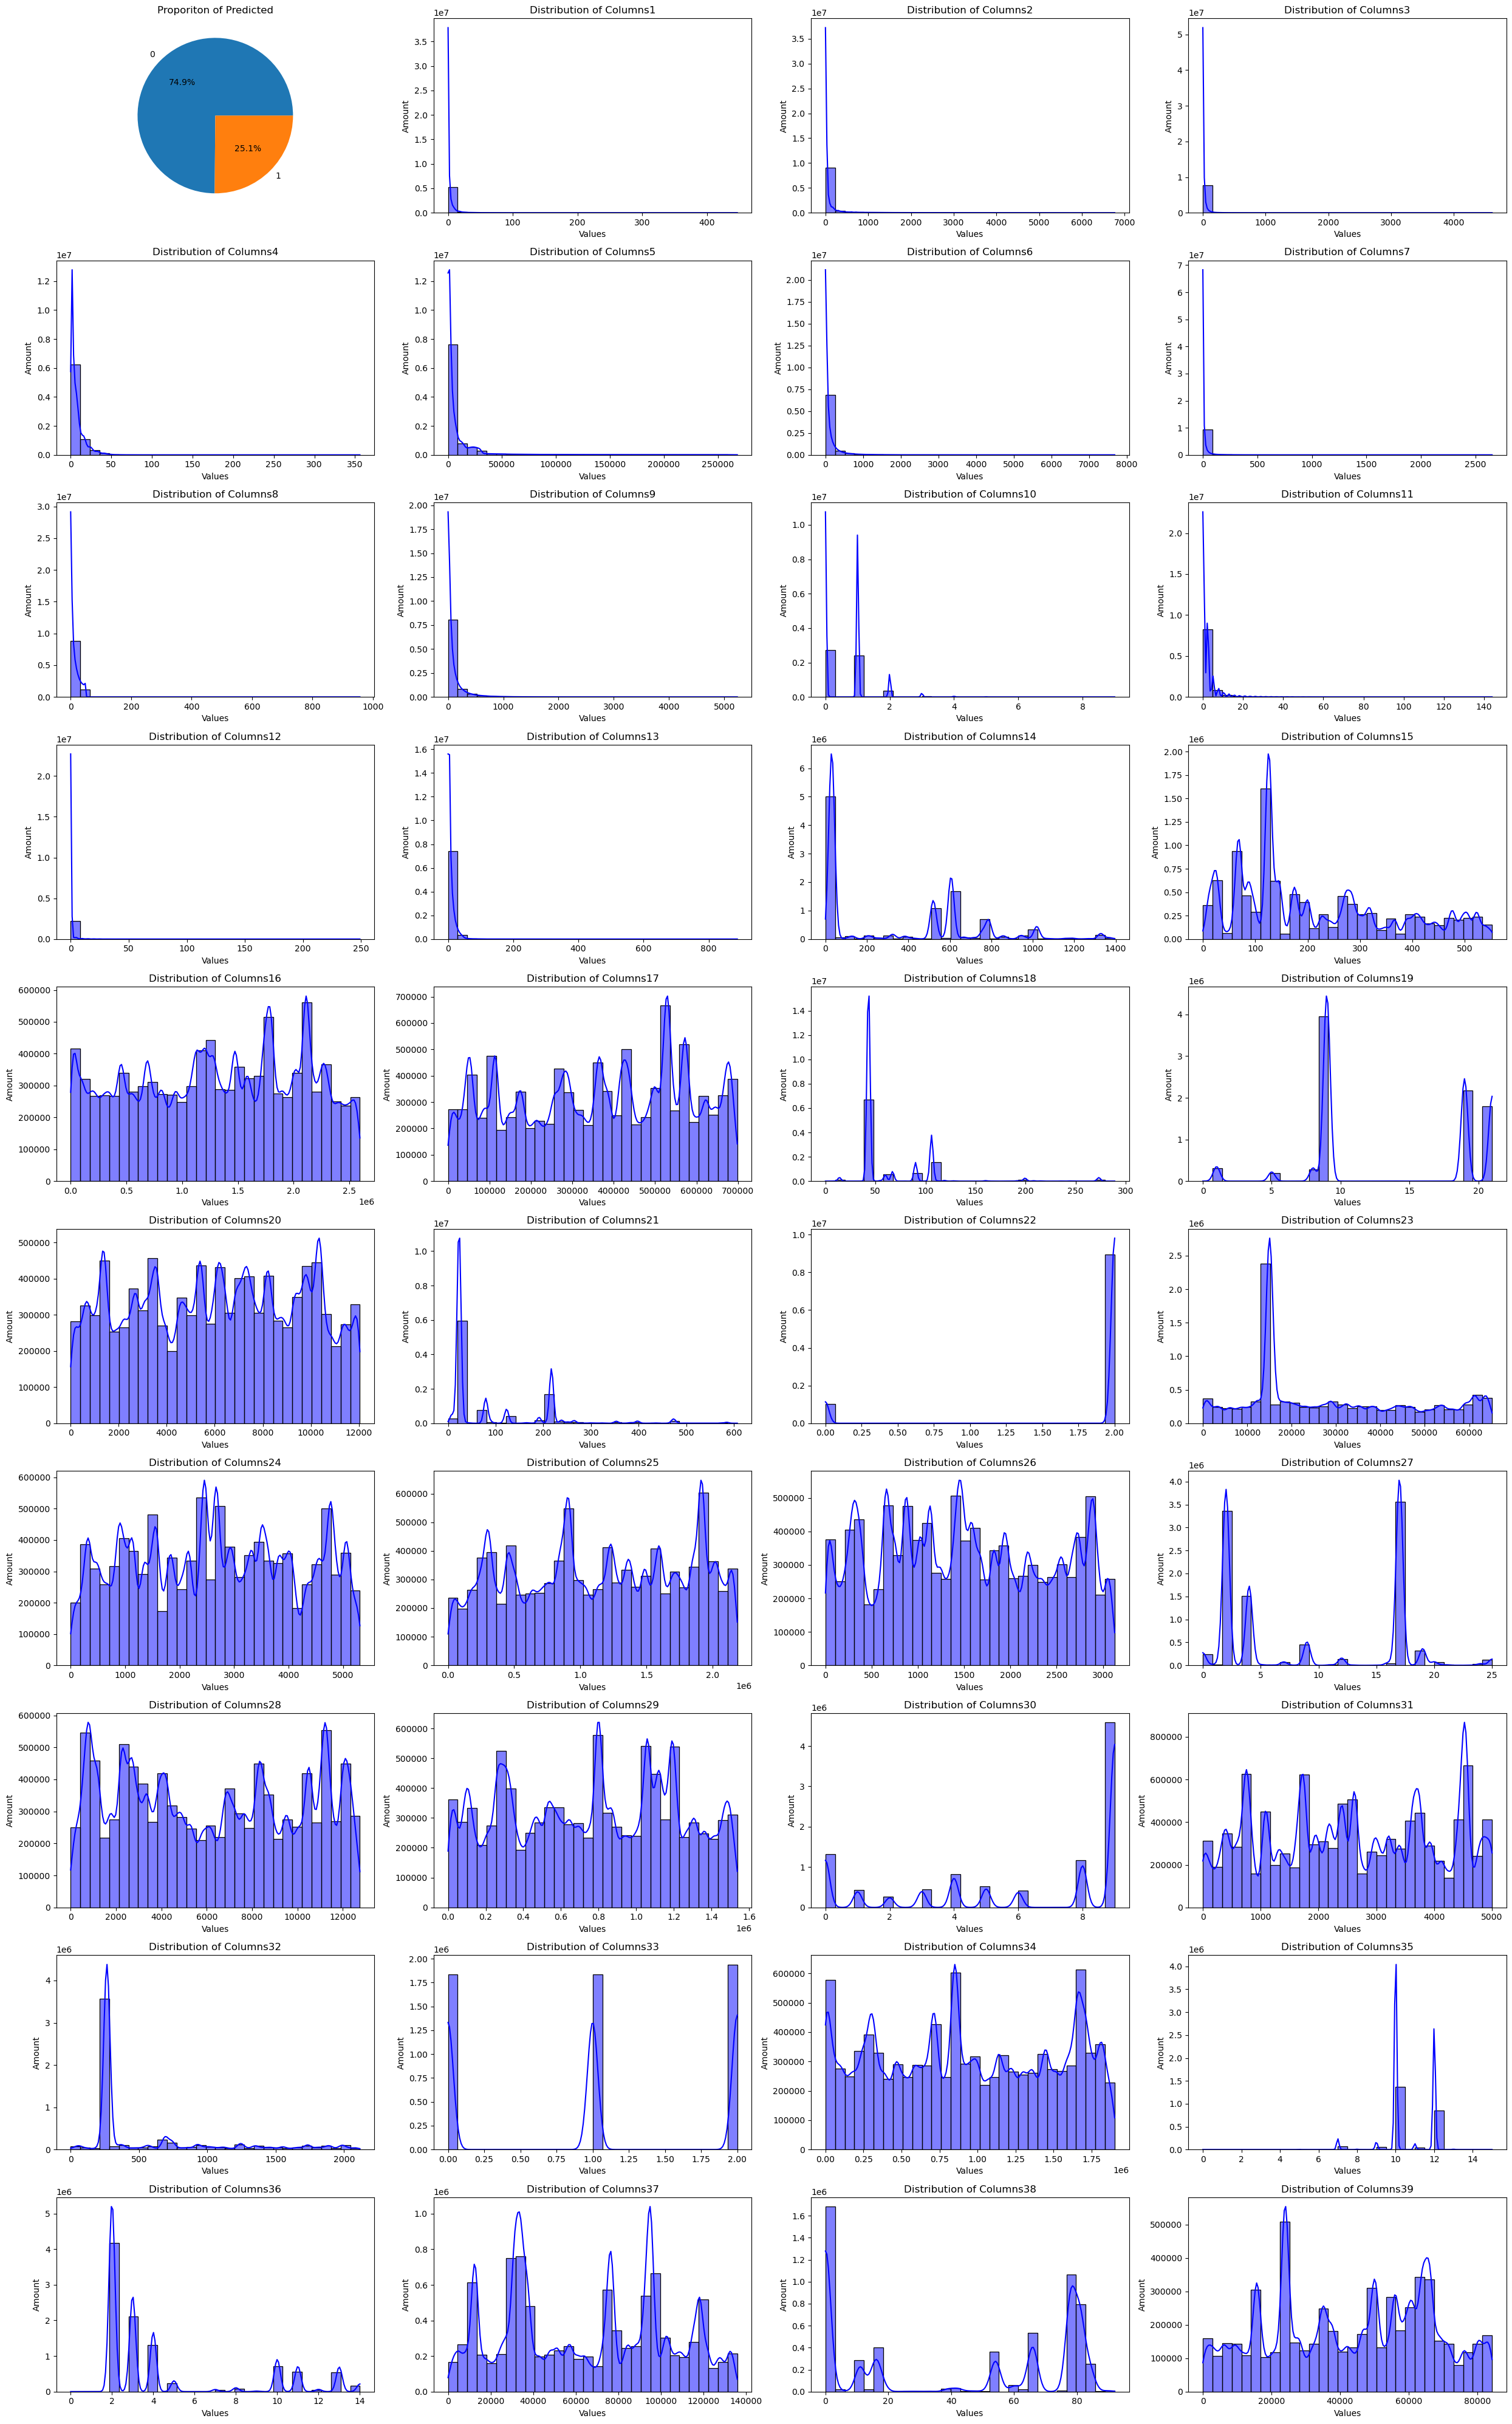

In [27]:
ColumnsHist(df_chunk1)

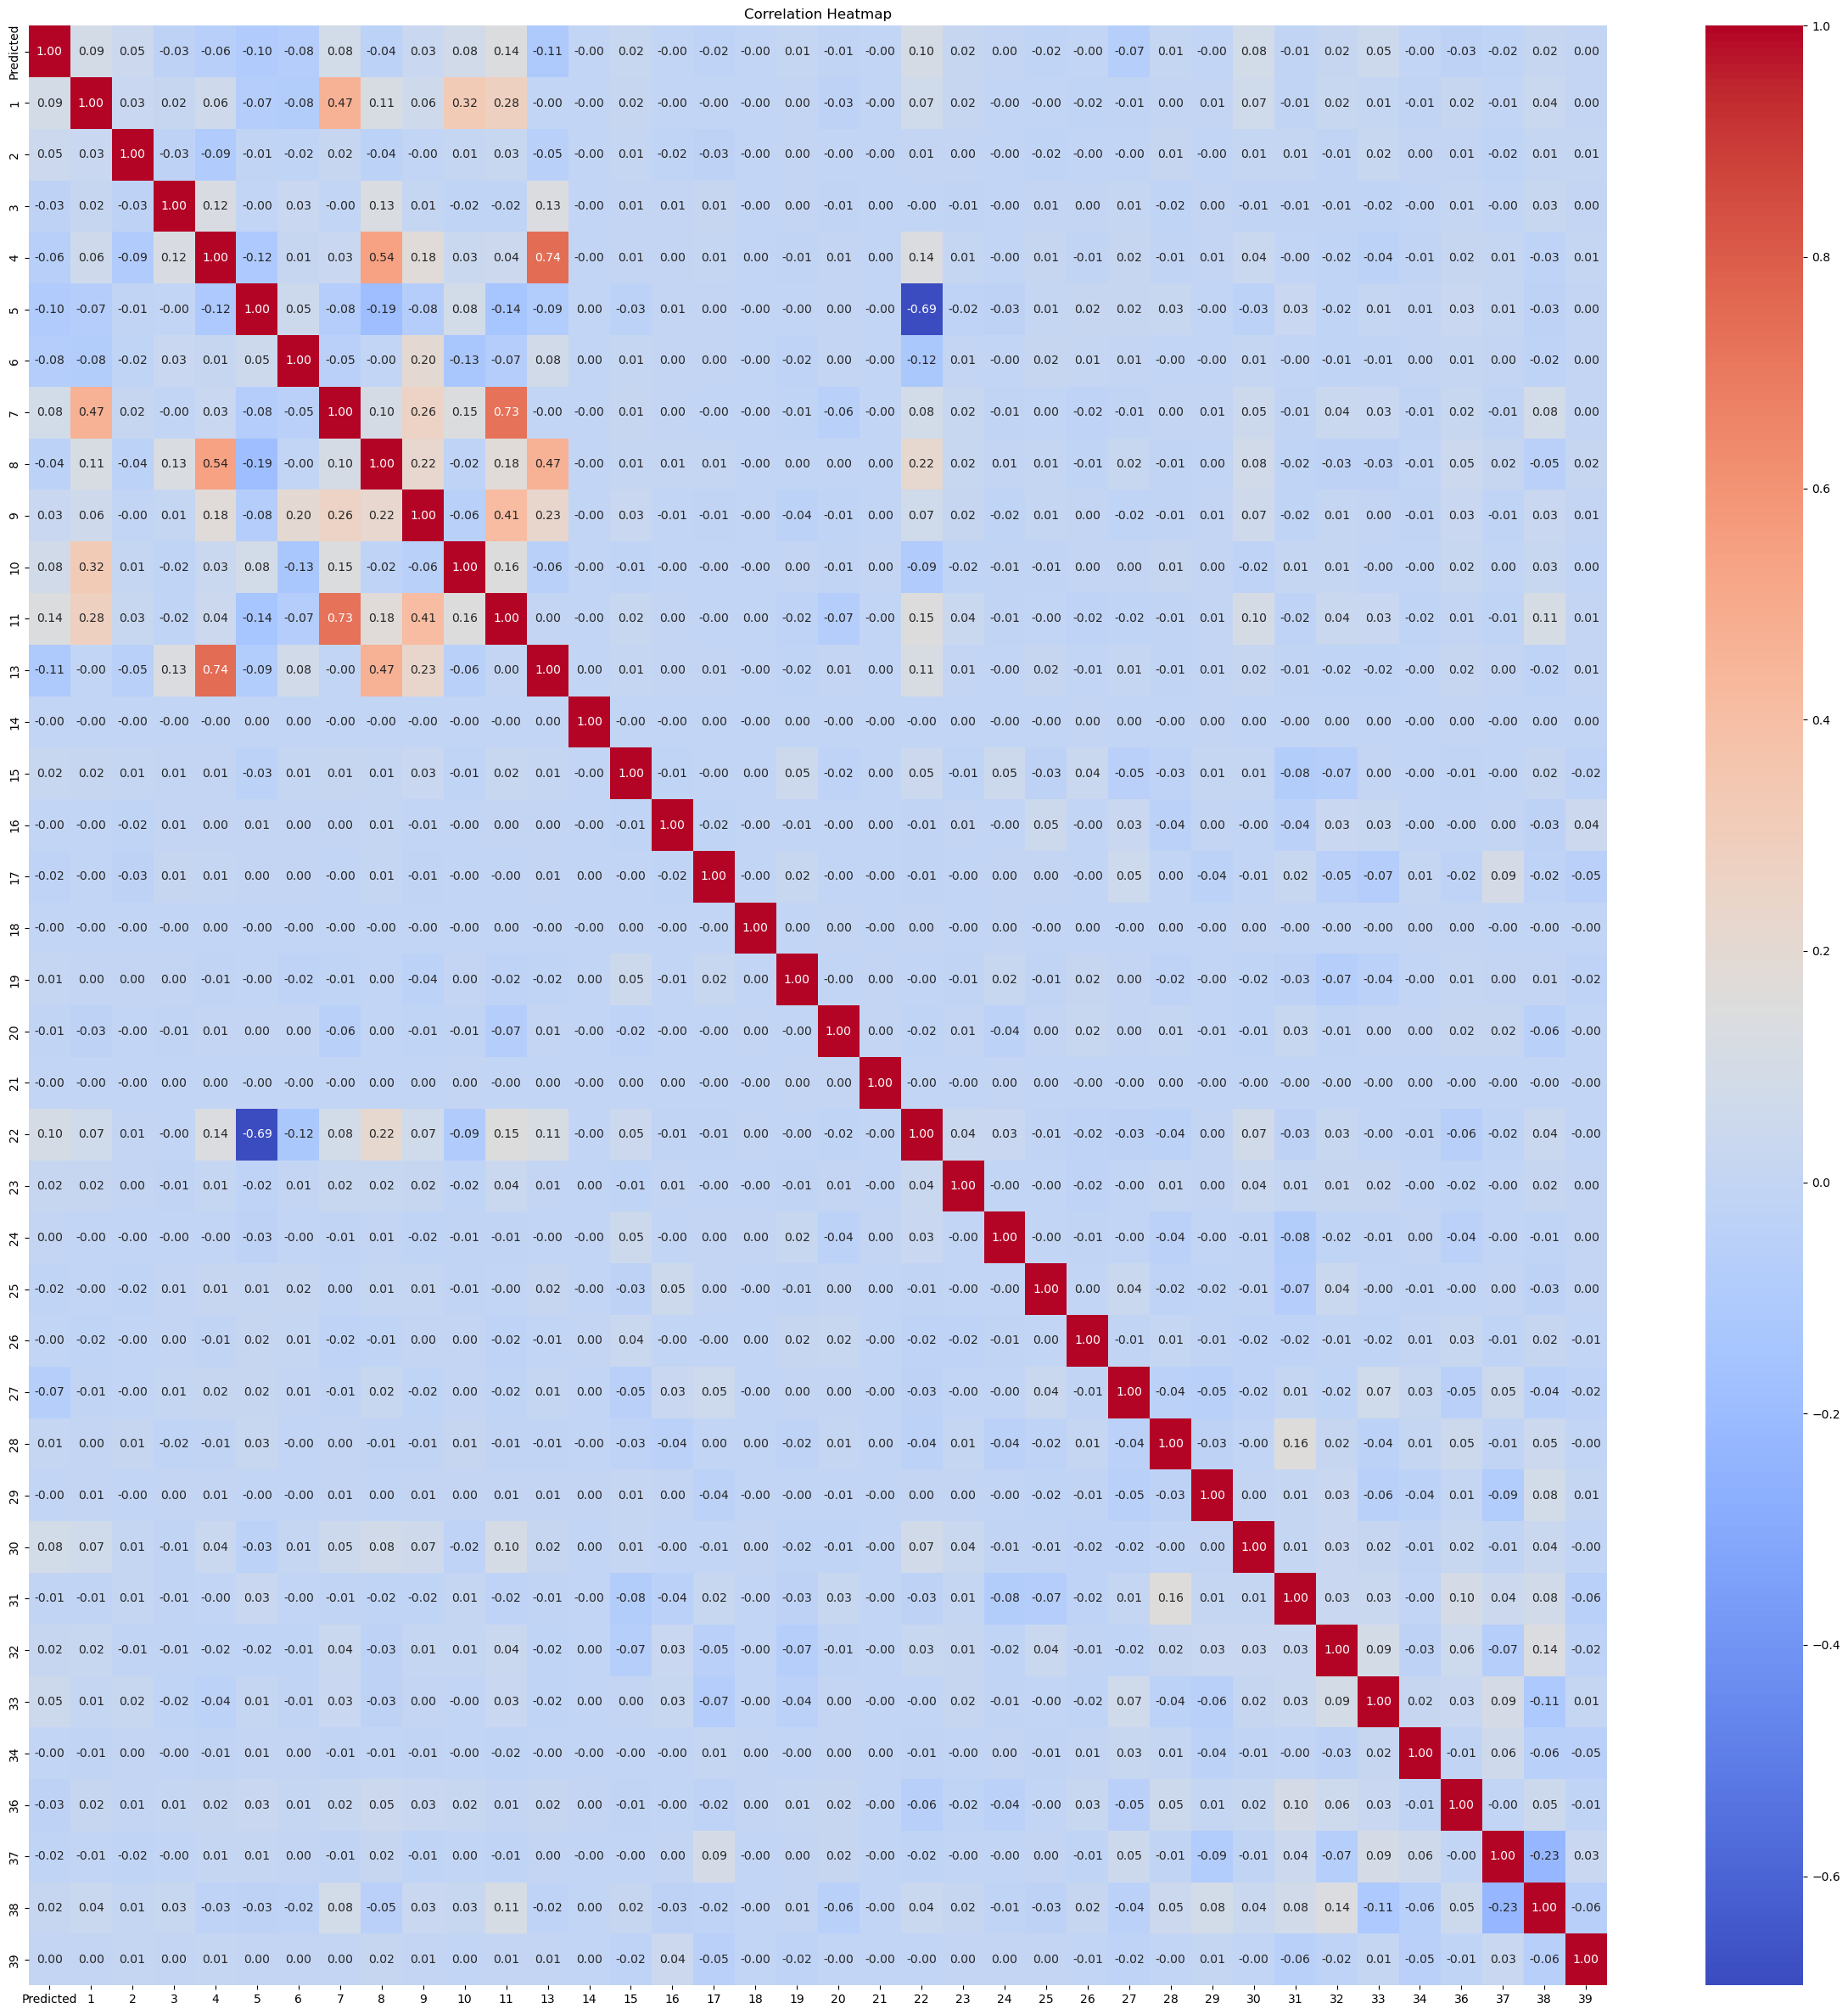

In [43]:
CorrHeatMap(df_chunk1)

#### <span style="color:grey; font-weight:bold;">Check NaN & Remove</span>

In [29]:
ColumnsNaNSorted(df_chunk1)

12   76.95
35   76.03
1    44.30
10   44.30
39   43.88
38   43.88
33   43.88
32   43.88
6    22.82
4    22.03
13   22.03
3    21.48
19   12.80
11    4.41
7     4.41
9     4.41
34    3.45
25    3.45
37    3.45
17    3.45
16    3.45
29    3.45
5     2.71
8     0.05
dtype: float64



,Predicted,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,0,2.00,3,44.00,1.00,71.00,8.00,2.00,2.00,4.00,...,0,3397,265,0,719842,NaN,3,36054,78,37710
1,0,2.00,3,1.00,14.00,533.00,89.00,4.00,2.00,245.00,...,6,976,NaN,NaN,1705234,10,3,31281,NaN,NaN
2,0,NaN,896,NaN,NaN,3050.00,NaN,0.00,0.00,0.00,...,1,2233,NaN,NaN,796309,NaN,3,76980,NaN,NaN
3,0,3.00,2,NaN,0.00,2.00,0.00,3.00,0.00,0.00,...,1,729,NaN,NaN,250104,NaN,2,95135,NaN,NaN
4,0,NaN,2,NaN,NaN,8906.00,NaN,0.00,0.00,6.00,...,5,2806,NaN,NaN,267820,9,11,60947,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,1,NaN,5,38.00,NaN,12101.00,89.00,1.00,9.00,2.00,...,8,1456,932,2,545539,12,2,119760,18,24147
9999996,0,0.00,87,2.00,2.00,1962.00,100.00,36.00,12.00,179.00,...,6,4738,265,2,892075,NaN,10,25118,84,26849
9999997,1,NaN,16,NaN,1.00,5018.00,NaN,0.00,1.00,12.00,...,5,4358,NaN,NaN,438606,12,2,42381,NaN,NaN
9999998,0,NaN,3,28.00,17.00,3017.00,NaN,0.00,31.00,193.00,...,9,4125,NaN,NaN,581,10,10,31281,NaN,NaN


In [30]:
RemovedColumnOver50(df_chunk1)

Removed Columns List: ['12', '35']



,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,0,2.00,3,44.00,1.00,71.00,8.00,2.00,2.00,4.00,...,1207693,0,3397,265,0,719842,3,36054,78,37710
1,0,2.00,3,1.00,14.00,533.00,89.00,4.00,2.00,245.00,...,324731,6,976,NaN,NaN,1705234,3,31281,NaN,NaN
2,0,NaN,896,NaN,NaN,3050.00,NaN,0.00,0.00,0.00,...,496375,1,2233,NaN,NaN,796309,3,76980,NaN,NaN
3,0,3.00,2,NaN,0.00,2.00,0.00,3.00,0.00,0.00,...,10180,1,729,NaN,NaN,250104,2,95135,NaN,NaN
4,0,NaN,2,NaN,NaN,8906.00,NaN,0.00,0.00,6.00,...,935499,5,2806,NaN,NaN,267820,11,60947,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,1,NaN,5,38.00,NaN,12101.00,89.00,1.00,9.00,2.00,...,897843,8,1456,932,2,545539,2,119760,18,24147
9999996,0,0.00,87,2.00,2.00,1962.00,100.00,36.00,12.00,179.00,...,474283,6,4738,265,2,892075,10,25118,84,26849
9999997,1,NaN,16,NaN,1.00,5018.00,NaN,0.00,1.00,12.00,...,487390,5,4358,NaN,NaN,438606,2,42381,NaN,NaN
9999998,0,NaN,3,28.00,17.00,3017.00,NaN,0.00,31.00,193.00,...,795592,9,4125,NaN,NaN,581,10,31281,NaN,NaN


#### <span style="color:grey; font-weight:bold;">Numerical Statistic & Impute</span>

In [31]:
numerical_chunk1, objective_chunk1 = SeparateNumericalandObjective(df_chunk1)

In [32]:
CountStatistic(numerical_chunk1)

Statistic of ColumnsPredicted
Mode: 0
Median: 0.0
AVG: 0.251

Statistic of Columns1
Mode: 0.0
Median: 1.0
AVG: 3.311

Statistic of Columns2
Mode: 3
Median: 6.0
AVG: 108.522

Statistic of Columns3
Mode: 1.0
Median: 6.0
AVG: 20.415

Statistic of Columns4
Mode: 1.0
Median: 4.0
AVG: 7.257

Statistic of Columns5
Mode: 1.0
Median: 1919.0
AVG: 10967.075

Statistic of Columns6
Mode: 0.0
Median: 33.0
AVG: 116.389

Statistic of Columns7
Mode: 0.0
Median: 3.0
AVG: 15.236

Statistic of Columns8
Mode: 0.0
Median: 7.0
AVG: 12.576

Statistic of Columns9
Mode: 1.0
Median: 38.0
AVG: 104.37

Statistic of Columns10
Mode: 0.0
Median: 1.0
AVG: 0.601

Statistic of Columns11
Mode: 1.0
Median: 1.0
AVG: 2.578

Statistic of Columns13
Mode: 1.0
Median: 4.0
AVG: 8.075



In [33]:
numerical_chunk1 = ImputeNaN(numerical_chunk1)

Predicted    0
1            0
2            0
3            0
4            0
5            0
6            0
7            0
8            0
9            0
10           0
11           0
13           0
dtype: int64



#### <span style="color:grey; font-weight:bold;">Check Objective NaN</span>

In [34]:
objective_missing_col1 = NaNColumns(objective_chunk1)
objective_missing_col1

,Predicted,16,17,19,25,29,32,33,34,37,38,39
0,0,1129558,177778,21,839962,1207693,265,0,719842,36054,78,37710
1,0,28571,528575,9,1229891,324731,NaN,NaN,1705234,31281,NaN,NaN
2,0,1719252,125493,21,1393322,496375,NaN,NaN,796309,76980,NaN,NaN
3,0,2028108,679768,1,877575,10180,NaN,NaN,250104,95135,NaN,NaN
4,0,396950,229394,8,1625157,935499,NaN,NaN,267820,60947,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,1,880474,337126,21,408977,897843,932,2,545539,119760,18,24147
9999996,0,1720950,294141,9,2083017,474283,265,2,892075,25118,84,26849
9999997,1,2357771,521785,9,2106091,487390,NaN,NaN,438606,42381,NaN,NaN
9999998,0,2110289,528575,9,1911224,795592,NaN,NaN,581,31281,NaN,NaN


<Axes: >

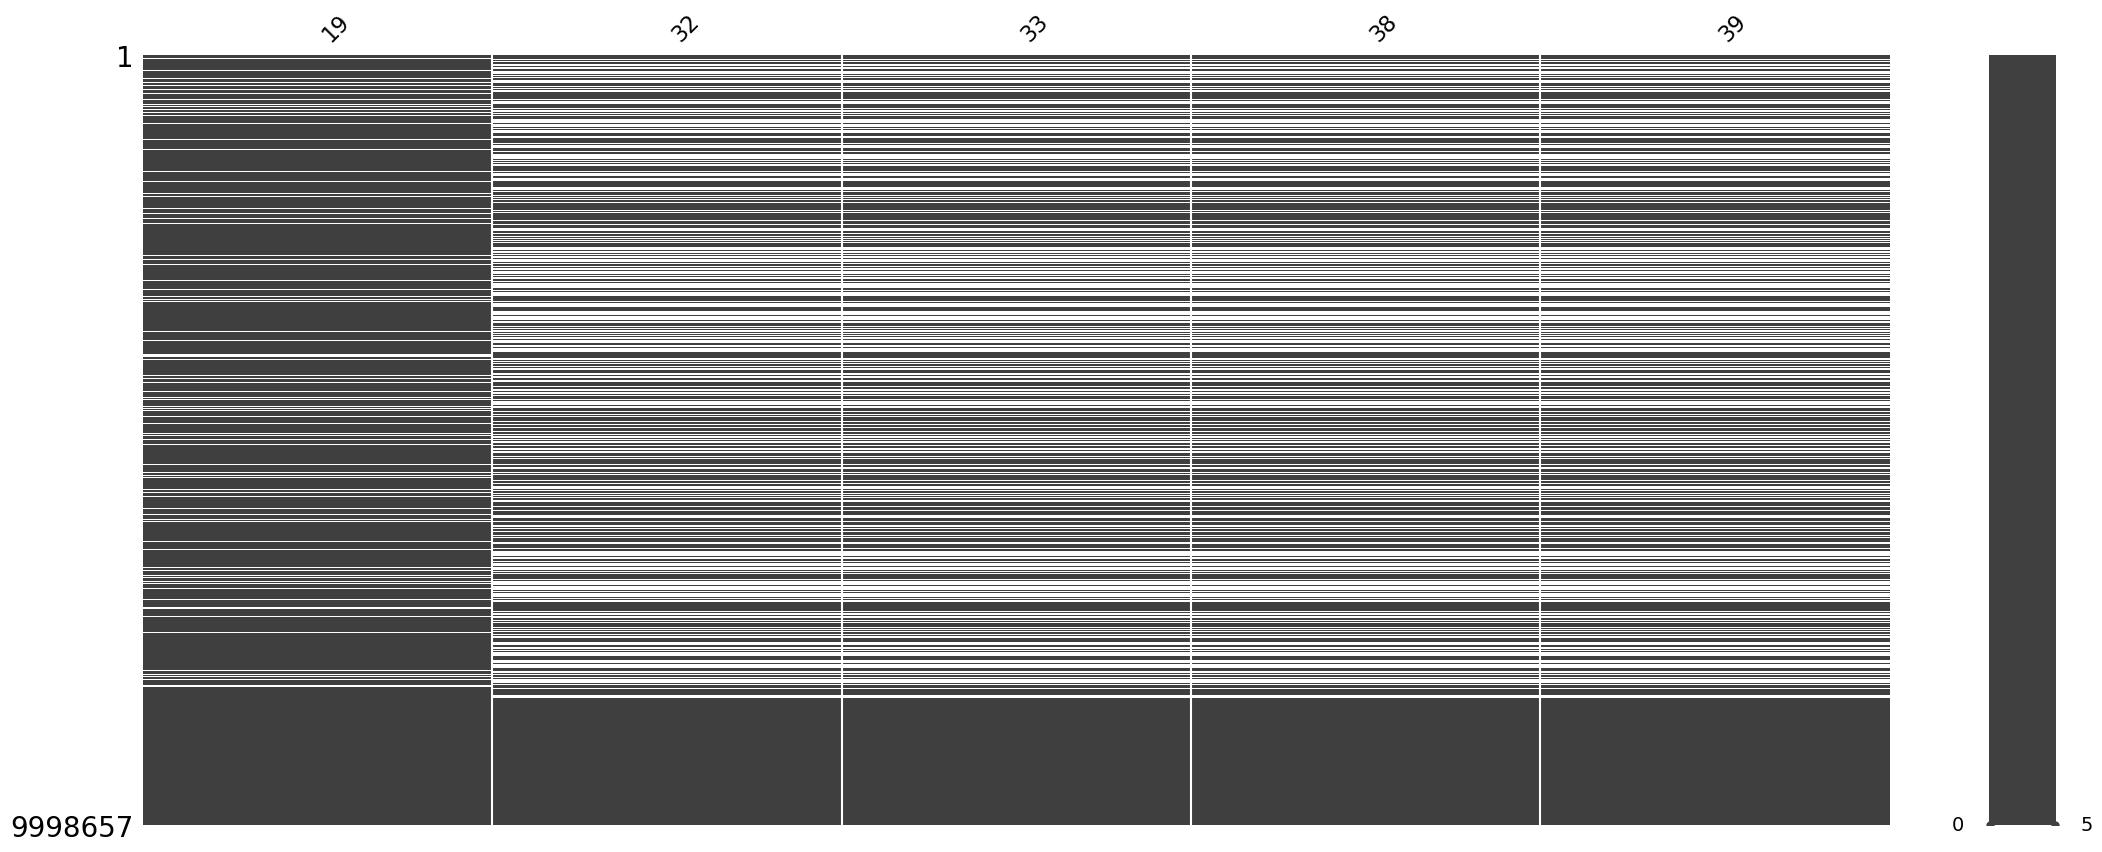

In [35]:
msno.matrix(objective_missing_col1[['19', '32', '33', '38', '39']])

<Axes: >

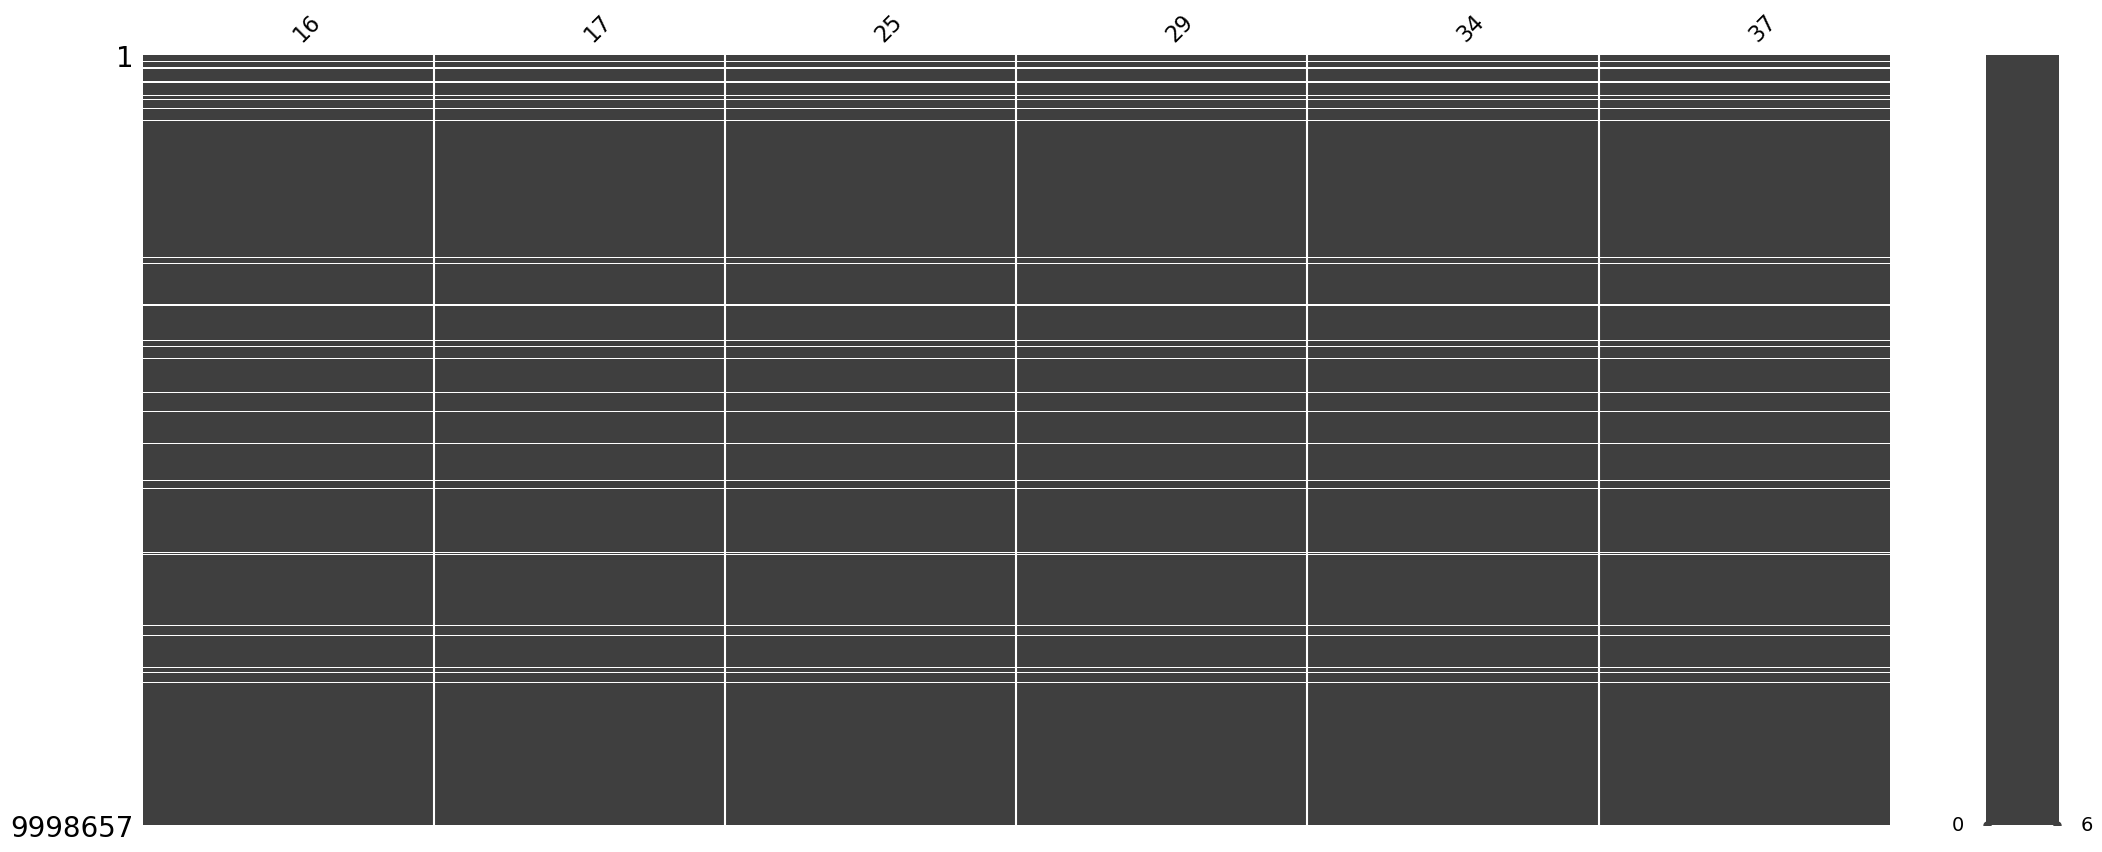

In [36]:
msno.matrix(objective_missing_col1[['16', '17', '25', '29', '34', '37']])

#### <span style="color:grey; font-weight:bold;">Fill & Drop NaN</span>

In [37]:
df_chunk1 = MergeAllTypeofColumns(numerical_chunk1, objective_chunk1)

In [38]:
filterd_columns = FilterColumns(df_chunk1, '19')
df_chunk1 = DropSpecificRowNaN(df_chunk1, filterd_columns)
df_chunk1

Row Before Drop: 9998657
Row After Drop: 5533570
Columns 16 Missing After Drop: 0
Columns 17 Missing After Drop: 0
Columns 25 Missing After Drop: 0
Columns 29 Missing After Drop: 0
Columns 32 Missing After Drop: 0
Columns 33 Missing After Drop: 0
Columns 34 Missing After Drop: 0
Columns 37 Missing After Drop: 0
Columns 38 Missing After Drop: 0
Columns 39 Missing After Drop: 0


,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,0.00,2.00,3.00,44.00,1.00,71.00,8.00,2.00,2.00,4.00,...,1207693,0,3397,265,0,719842,3,36054,78,37710
1,0.00,1.00,5.00,632.00,0.00,39397.00,33.00,0.00,5.00,65.00,...,122474,5,213,265,0,1515269,3,109766,81,50721
2,1.00,1.00,5.00,11.00,5.00,7127.00,34.00,2.00,4.00,5.00,...,47429,0,2627,187,1,1193530,2,85017,54,45167
3,0.00,0.00,54.00,84.00,4.00,2523.00,26.00,1.00,4.00,8.00,...,263299,4,351,265,2,1858253,14,75814,78,64578
4,1.00,1.00,990.00,6.00,2.00,73.00,2.00,1.00,2.00,2.00,...,282304,8,1675,265,2,438551,2,94484,0,56025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5533565,1.00,1.00,24.00,11.00,19.00,4348.00,33.00,0.00,28.00,169.00,...,145204,1,1675,265,0,235767,3,5591,0,70602
5533566,0.00,5.00,3.00,12.00,15.00,27.00,18.00,11.00,26.00,100.00,...,1310101,9,9,265,2,542586,2,12443,78,61061
5533567,0.00,1.00,4.00,4.00,6.00,3017.00,32.00,18.00,8.00,50.00,...,1190584,3,1912,1735,0,709671,4,12443,78,60543
5533568,1.00,1.00,5.00,38.00,4.00,12101.00,89.00,1.00,9.00,2.00,...,897843,8,1456,932,2,545539,2,119760,18,24147


In [39]:
ModelFillNaN(df_chunk1, '19')

/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis/Def_Function.py:289: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model = DecisionTreeClassifier(random_state=42)


Columns 19 FillNaN is Finished



,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,0.00,2.00,3.00,44.00,1.00,71.00,8.00,2.00,2.00,4.00,...,1207693,0,3397,265,0,719842,3,36054,78,37710
1,0.00,1.00,5.00,632.00,0.00,39397.00,33.00,0.00,5.00,65.00,...,122474,5,213,265,0,1515269,3,109766,81,50721
2,1.00,1.00,5.00,11.00,5.00,7127.00,34.00,2.00,4.00,5.00,...,47429,0,2627,187,1,1193530,2,85017,54,45167
3,0.00,0.00,54.00,84.00,4.00,2523.00,26.00,1.00,4.00,8.00,...,263299,4,351,265,2,1858253,14,75814,78,64578
4,1.00,1.00,990.00,6.00,2.00,73.00,2.00,1.00,2.00,2.00,...,282304,8,1675,265,2,438551,2,94484,0,56025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5533565,1.00,1.00,24.00,11.00,19.00,4348.00,33.00,0.00,28.00,169.00,...,145204,1,1675,265,0,235767,3,5591,0,70602
5533566,0.00,5.00,3.00,12.00,15.00,27.00,18.00,11.00,26.00,100.00,...,1310101,9,9,265,2,542586,2,12443,78,61061
5533567,0.00,1.00,4.00,4.00,6.00,3017.00,32.00,18.00,8.00,50.00,...,1190584,3,1912,1735,0,709671,4,12443,78,60543
5533568,1.00,1.00,5.00,38.00,4.00,12101.00,89.00,1.00,9.00,2.00,...,897843,8,1456,932,2,545539,2,119760,18,24147


#### <span style="color:grey; font-weight:bold;">Numerical Skew</span>

In [44]:
numerical_df_skew = df_chunk1.loc[:, 'Predicted':'13']
objective_df_skew = df_chunk1.loc[:, '14':]

In [45]:
negative_list = CheckNegativeColumns(numerical_df_skew)
print(negative_list)

[]


In [46]:
SkewCountingandTransformWithoutHist(numerical_df_skew, negative_list)

Procseeing 1
Original Column 1 Skew: 14.10
Column 1 transform by Boxcox has lower Skew: 0.08
Procseeing 2
Original Column 2 Skew: 6.57
Column 2 transform by Boxcox has lower Skew: 0.41
Procseeing 3
Original Column 3 Skew: 25.42
Column 3 transform by Boxcox has lower Skew: 0.05
Procseeing 4
Original Column 4 Skew: 2.92
Column 4 transform by Boxcox has lower Skew: 0.00
Procseeing 5
Original Column 5 Skew: 5.09
Column 5 transform by Boxcox has lower Skew: -0.04
Procseeing 6
Original Column 6 Skew: 11.40
Column 6 transform by Boxcox has lower Skew: 0.01
Procseeing 7
Original Column 7 Skew: 15.87
Column 7 transform by Boxcox has lower Skew: 0.10
Procseeing 8
Original Column 8 Skew: 1.17
Column 8 transform by Boxcox has lower Skew: -0.05
Procseeing 9
Original Column 9 Skew: 7.31
Column 9 transform by Boxcox has lower Skew: -0.01
Procseeing 10
Original Column 10 Skew: 0.46
Columns 10 Skew is not in range for transform
Procseeing 11
Original Column 11 Skew: 6.11
Column 11 transform by Boxcox h

,Predicted,1,2,3,4,5,6,7,8,9,10,11,13
0,0.00,0.78,1.01,2.51,0.67,5.23,2.30,0.97,1.19,1.67,1.00,0.59,1.45
1,0.00,0.56,1.21,3.30,0.00,17.78,3.81,0.00,2.03,4.62,1.00,0.00,1.02
2,1.00,0.56,1.21,1.88,1.62,13.64,3.84,0.97,1.80,1.87,1.00,0.59,1.60
3,0.00,0.00,1.79,2.75,1.47,11.42,3.54,0.64,1.80,2.31,0.00,0.59,1.45
4,1.00,0.56,2.02,1.56,1.03,5.27,1.12,0.64,1.19,1.13,1.00,0.59,1.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5533565,1.00,0.56,1.65,1.88,2.54,12.56,3.81,0.00,4.28,5.79,1.00,0.00,2.48
5533566,0.00,1.05,1.01,1.92,2.38,3.89,3.14,1.88,4.16,5.14,2.00,1.14,2.24
5533567,0.00,0.56,1.12,1.34,1.74,11.79,3.77,2.12,2.56,4.31,1.00,1.03,1.72
5533568,1.00,0.56,1.21,2.45,1.47,14.85,4.96,0.64,2.71,1.13,1.00,0.59,1.45


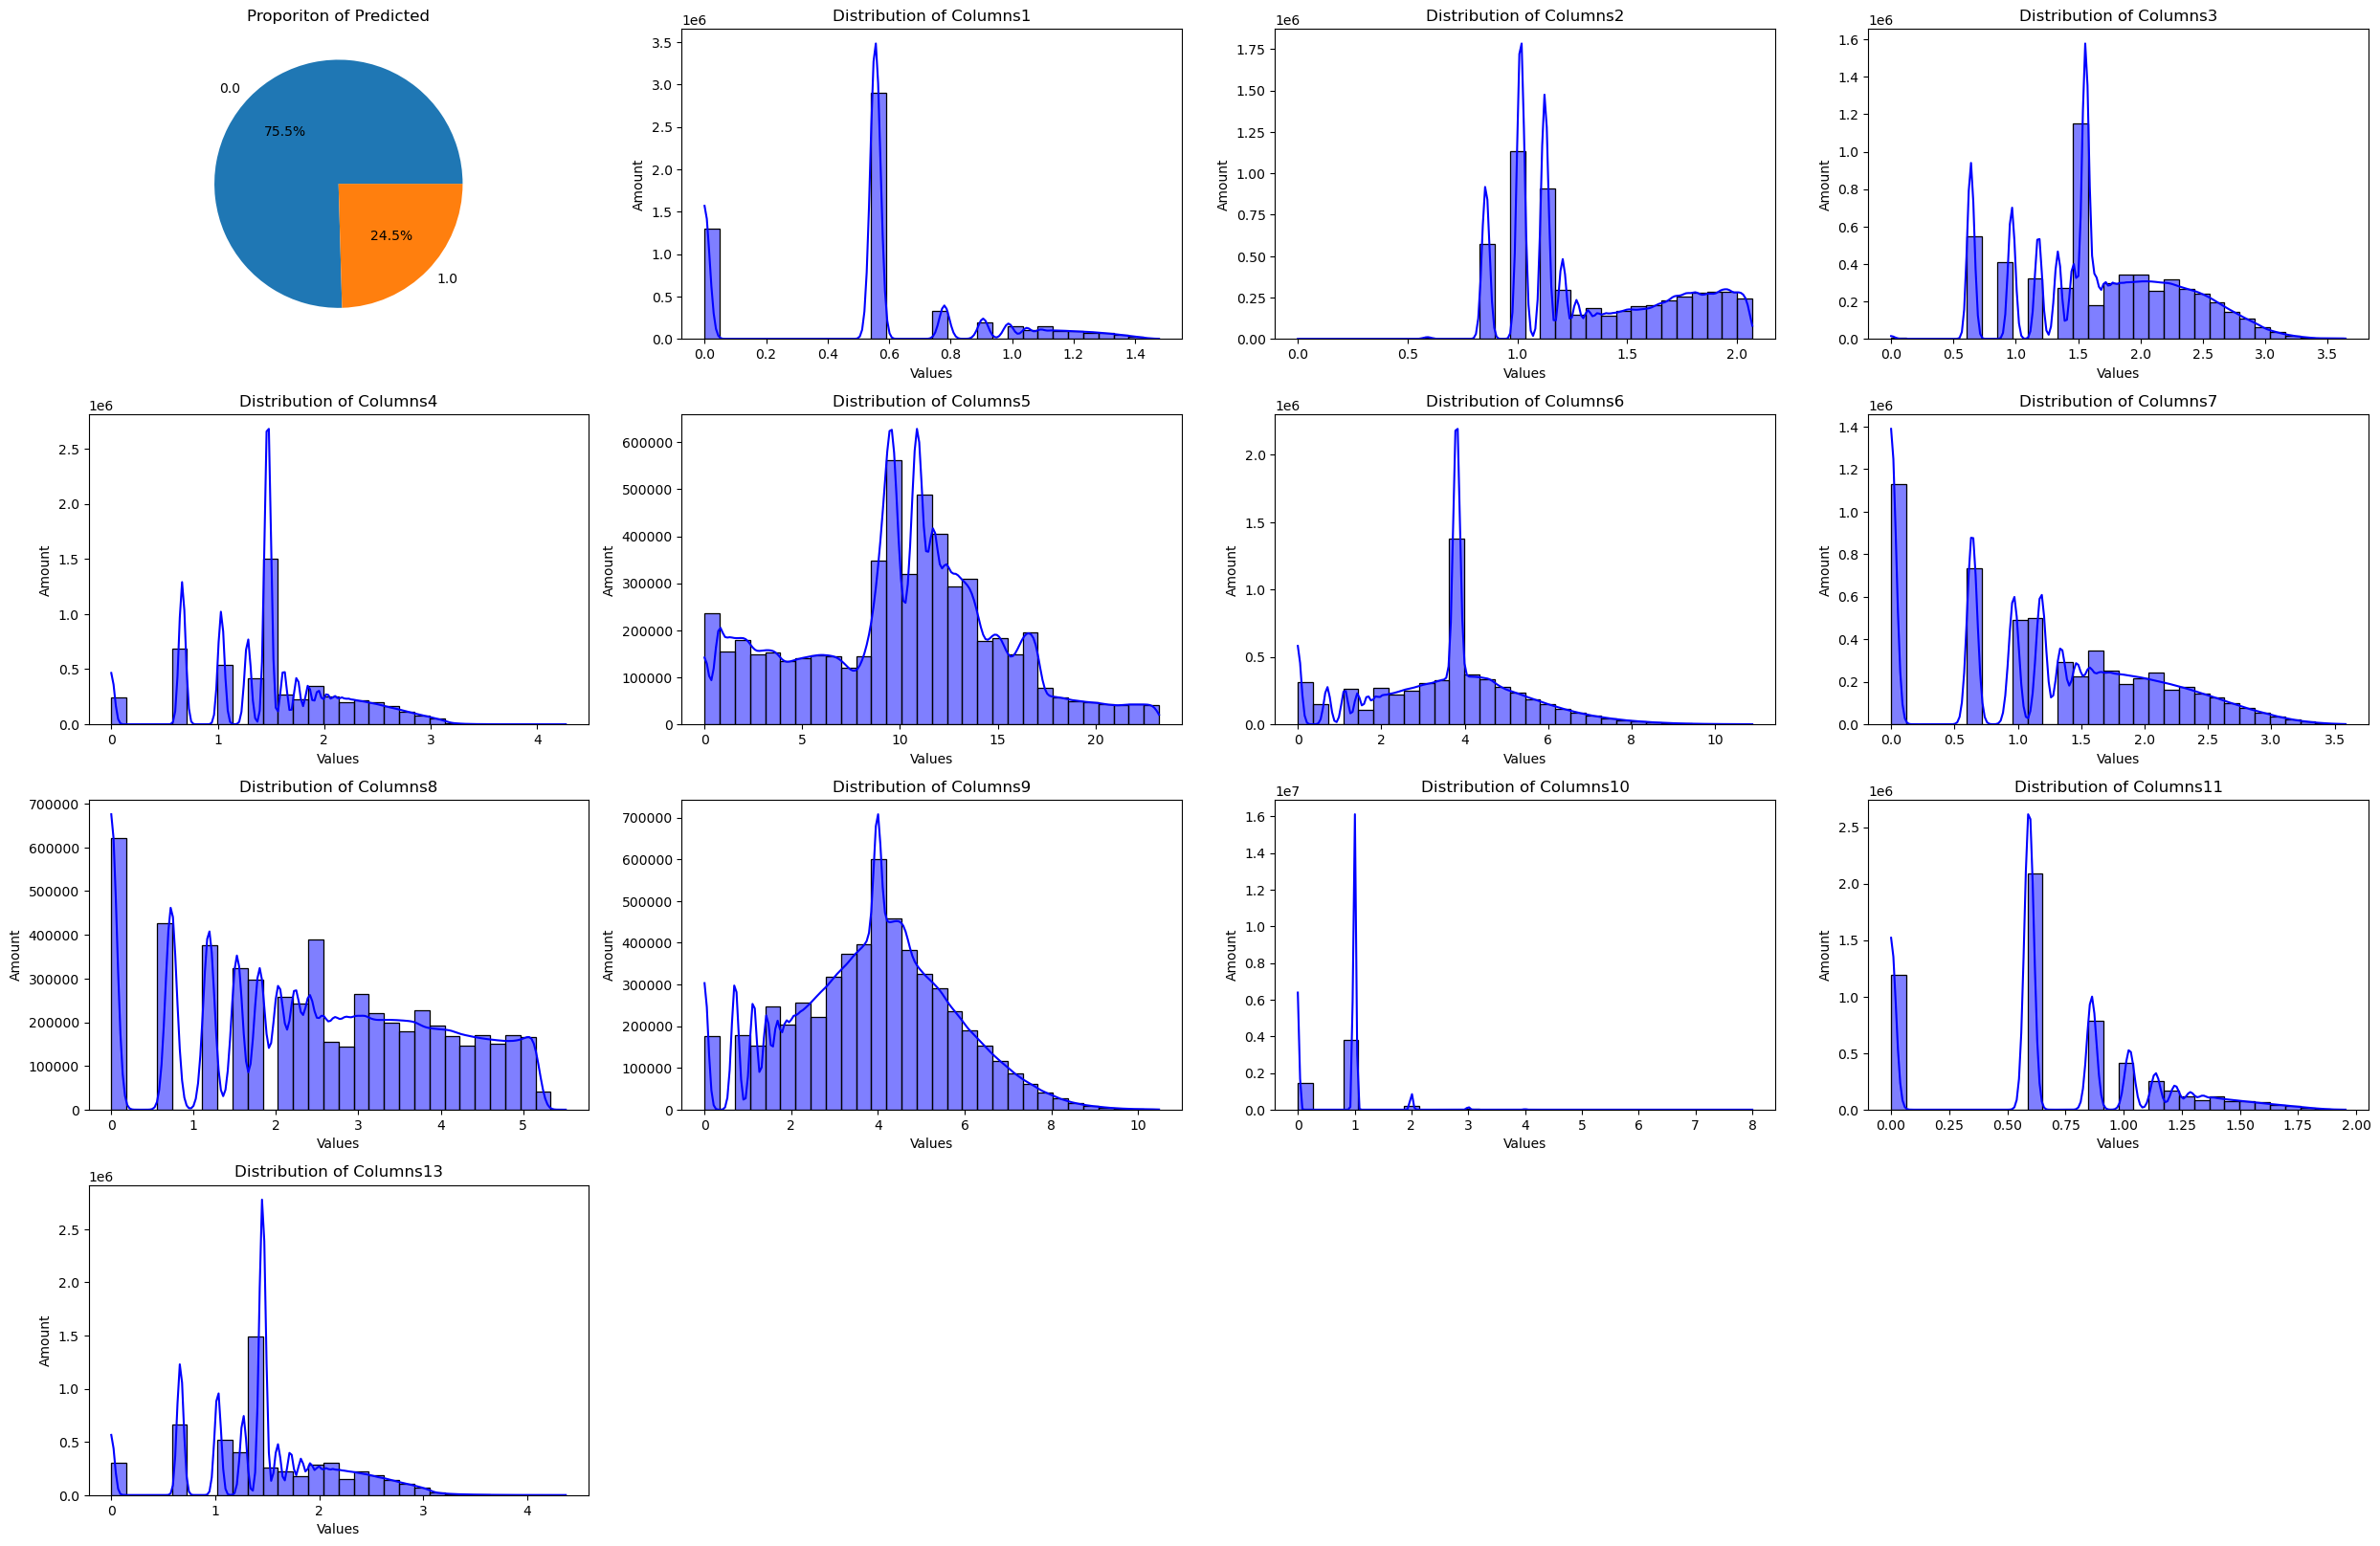

In [47]:
ColumnsHist(numerical_df_skew)

In [48]:
df_chunk1 = MergeAllTypeofColumns(numerical_df_skew, objective_df_skew)

In [49]:
SaveCSV(df_chunk1, 'Data Preprocessing', '1')

Saved Data Preprocessing Chunk 1


## <span style="color:skyblue; font-weight:bold;">Chunk 2</span>

#### <span style="color:grey; font-weight:bold;">EDA</span>

#### <span style="color:grey; font-weight:bold;">Rename & Deleted Duplicated</span>

#### <span style="color:grey; font-weight:bold;">Objective LabelEncoder</span>

#### <span style="color:grey; font-weight:bold;">HistPlot & HeatMap</span>

#### <span style="color:grey; font-weight:bold;">Check NaN & Remove</span>

#### <span style="color:grey; font-weight:bold;">Numerical Statistic & Impute</span>

#### <span style="color:grey; font-weight:bold;">Check Objective NaN</span>

#### <span style="color:grey; font-weight:bold;">Fill & Drop NaN</span>

#### <span style="color:grey; font-weight:bold;">Numerical Skew</span>